# Phase 1 — EDA
## Fase 1 — EDA

**Marginalia — Your literary assistant.**  
*Marginalia — Tu asistente literario.*

---

This notebook ...

*Este notebook ...*


**What this phase produces / Qué produce esta fase:**


In [ ]:
# ============================================================
# LIBRERIAS
# ============================================================

# Instalamos rapidfuzz, que necesitaremos para la deduplicación difusa
!pip install rapidfuzz -q

# Librerías estándar de análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from collections import Counter
import ast
import re
from rapidfuzz import fuzz
import warnings
warnings.filterwarnings('ignore')

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (12, 5)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [ ]:
# ============================================================
# CARGA DEL DATASET
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/PF_Ironhack/books_database_final.csv"

df = pd.read_csv(CSV_PATH, dtype={"isbn_13": str, "isbn_10": str}  # Evitar notación científica
)

print("=" * 60)
print("FASE 1 — EDA DEL DATASET DE LIBROS")
print("=" * 60)
print(f"\n Dataset cargado correctamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n   Nombres de columnas:")
for col in df.columns:
    print(f"     - {col}")

print("\n--- PRIMERAS 3 FILAS ---")
print(df.head(3).to_string())

print("\n--- TIPOS DE DATOS POR COLUMNA ---")
print(df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FASE 1 — EDA DEL DATASET DE LIBROS

 Dataset cargado correctamente
   Filas    : 10,951
   Columnas : 12

   Nombres de columnas:
     - title
     - authors
     - publisher
     - description
     - categories
     - assigned_category
     - page_count
     - year
     - isbn_13
     - isbn_10
     - thumbnail
     - info_link

--- PRIMERAS 3 FILAS ---
                                                     title           authors                  publisher                                                                                                                                                                                                                                                                                                                                                                                                                           

--- VALORES NULOS POR COLUMNA ---

                   Nulos  Porcentaje (%)
isbn_10             2622           23.94
isbn_13             2211           20.19
publisher           1443           13.18
categories           708            6.47
thumbnail            375            3.42
year                 141            1.29
page_count            68            0.62
description            0            0.00
title                  0            0.00
authors                0            0.00
assigned_category      0            0.00
info_link              0            0.00
desc_len               0            0.00
categories_list        0            0.00


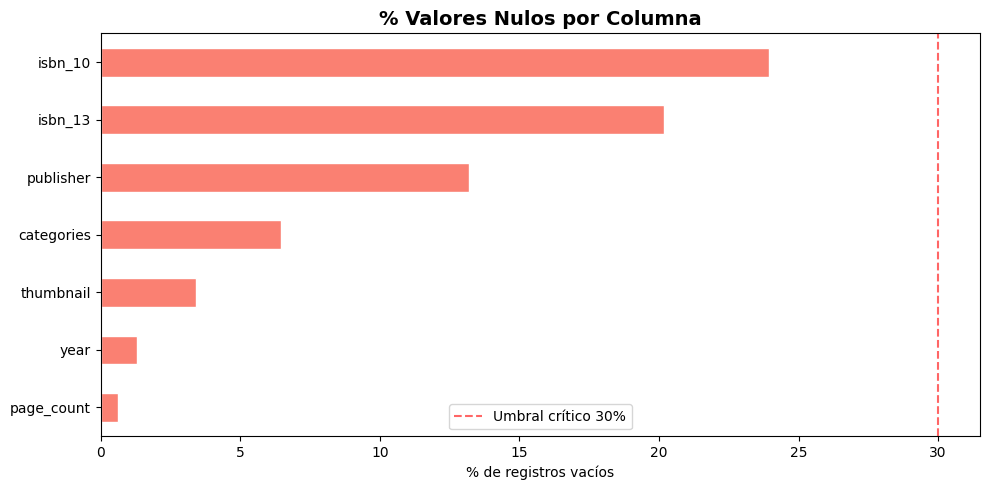

In [ ]:
# ============================================================
# VALORES NULOS
# ============================================================

nulls    = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Nulos': nulls,
    'Porcentaje (%)': null_pct
}).sort_values('Porcentaje (%)', ascending=False)

print("--- VALORES NULOS POR COLUMNA ---\n")
print(null_df.to_string())

# ============================================================
# GRÁFICO: columnas con mayor porcentaje de nulos
# ============================================================
columnas_con_nulos = null_pct[null_pct > 0].sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
columnas_con_nulos.plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_title("% Valores Nulos por Columna", fontsize=14, fontweight='bold')
ax.set_xlabel("% de registros vacíos")
# Línea roja en 30%: si una columna supera esto, es problemática
ax.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Umbral crítico 30%')
ax.legend()
plt.tight_layout()
plt.show()


--- ANÁLISIS DE 'description' ---

   Total libros          : 10,951
   Con descripción       : 10,951
   Vacías (0 chars)      : 0

   Longitud promedio     : 991 caracteres
   Longitud mediana      : 892 caracteres
   Descripción más corta : 1 caracteres
   Descripción más larga : 14,015 caracteres
   Descripciones < 100 chars (muy cortas): 451
   Descripciones >= 100 chars (útiles)   : 10,500


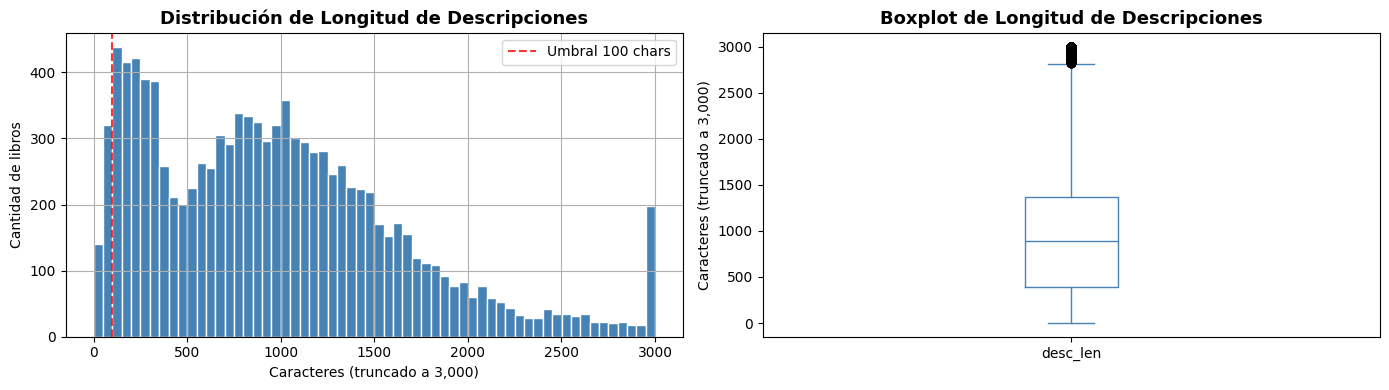

In [ ]:
# ============================================================
# ANÁLISIS DE 'description'
# Esta es la columna MÁS IMPORTANTE del pipeline.
# ============================================================

# Calculamos la longitud en caracteres de cada descripción
# Usamos fillna('') por si acaso hay algún nulo no detectado
df['desc_len'] = df['description'].fillna('').apply(len)

print("--- ANÁLISIS DE 'description' ---\n")
print(f"   Total libros          : {len(df):,}")
print(f"   Con descripción       : {(df['desc_len'] > 0).sum():,}")
print(f"   Vacías (0 chars)      : {(df['desc_len'] == 0).sum():,}")
print(f"\n   Longitud promedio     : {df['desc_len'].mean():.0f} caracteres")
print(f"   Longitud mediana      : {df['desc_len'].median():.0f} caracteres")
print(f"   Descripción más corta : {df['desc_len'].min()} caracteres")
print(f"   Descripción más larga : {df['desc_len'].max():,} caracteres")

# Umbrales de calidad
# < 100 chars = muy corta, poco contexto
print(f"   Descripciones < 100 chars (muy cortas): {(df['desc_len'] < 100).sum():,}")
print(f"   Descripciones >= 100 chars (útiles)   : {(df['desc_len'] >= 100).sum():,}")


# ============================================================
# GRÁFICO: distribución de longitudes
# clip(upper=3000) recorta el eje X en 3000 chars para que
# el gráfico sea legible (hay outliers con descripciones muy largas)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Izquierdo: todas las descripciones con longitud > 0
df[df['desc_len'] > 0]['desc_len'].clip(upper=3000).hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("Distribución de Longitud de Descripciones", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Caracteres (truncado a 3,000)")
axes[0].set_ylabel("Cantidad de libros")
axes[0].axvline(x=100, color='red', linestyle='--', alpha=0.8, label='Umbral 100 chars')
axes[0].legend()

# Derecho: boxplot para ver la dispersión
df[df['desc_len'] > 0]['desc_len'].clip(upper=3000).plot(
    kind='box', ax=axes[1], color='steelblue'
)
axes[1].set_title("Boxplot de Longitud de Descripciones", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Caracteres (truncado a 3,000)")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# FILTRO 1 — Calidad de la descripción
# ============================================================
# Eliminamos libros en ambos extremos de longitud de descripción:
#
# MUY CORTAS (< 100 chars): no hay suficiente texto para que BERT
# o TF-IDF extraigan señal útil.
#
# MUY LARGAS (> 2500 chars): suelen ser previews de capítulos completos
# o texto de marketing. Sesgan los pesos TF-IDF y ralentizan BERT
# innecesariamente. 2500 chars (~400 palabras) es más que suficiente.

DESC_MIN =  100
DESC_MAX = 2500

before = len(df)

df_filtrado = df[
    (df['desc_len'] >= DESC_MIN) &
    (df['desc_len'] <= DESC_MAX)
].copy()

removed_short = (df['desc_len'] < DESC_MIN).sum()
removed_long  = (df['desc_len'] > DESC_MAX).sum()

print("--- FILTRO 1: Largo de la descripción ---\n")
print(f"   Dataset original         : {before:,} libros")
print(f"   Eliminados (< {DESC_MIN} chars) : {removed_short:,}")
print(f"   Eliminados (> {DESC_MAX} chars) : {removed_long:,}")
print(f"   Actualizado              : {len(df_filtrado):,} libros")

--- FILTRO 1: Largo de la descripción ---

   Dataset original         : 10,951 libros
   Eliminados (< 100 chars) : 451
   Eliminados (> 2500 chars) : 422
   Actualizado              : 10,078 libros


--- ANÁLISIS DE 'assigned_category' ---

   Categorías únicas : 23

   Distribución completa:
assigned_category
mystery_thriller                    910
fiction                             885
science_fiction                     856
historical_fiction                  840
self_help                           769
fantasy                             747
horror                              727
biography_memoir                    683
non_fiction                         579
young_adult                         541
graphic_novel_comics                410
romance                             366
classics_postmodern_american        365
classics_black_mountain_new_york    311
classics_realism                    299
classics_gothic_romantic            282
classics_latin_american             257
classics_modernism                  247
classics                            240
classics_existentialism             230
classics_postmodernism              206
award_winners                       116
classics

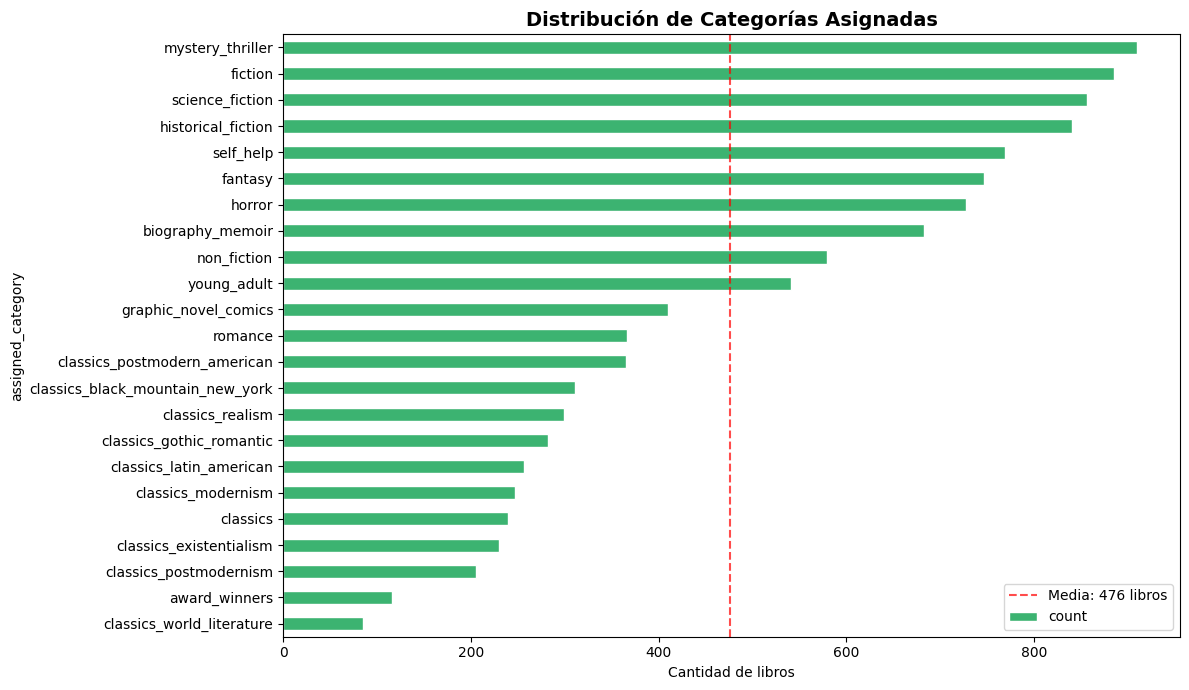


--- ANÁLISIS DE 'categories' (campo original) ---

   Muestra de valores crudos:
['Literary Collections', 'Literary Criticism', 'Juvenile Fiction', 'Education', 'Language Arts & Disciplines', 'Education', 'Literary Criticism', 'Literary Criticism']

   Total etiquetas únicas en 'categories' : 396

   Top 20 etiquetas:
     Fiction                                   3176 libros
     Literary Criticism                        1545 libros
     Biography & Autobiography                  514 libros
     Language Arts & Disciplines                435 libros
     History                                    402 libros
     Social Science                             273 libros
     Performing Arts                            222 libros
     Education                                  210 libros
     Business & Economics                       209 libros
     Literary Collections                       207 libros
     Psychology                                 184 libros
     Self-Help                

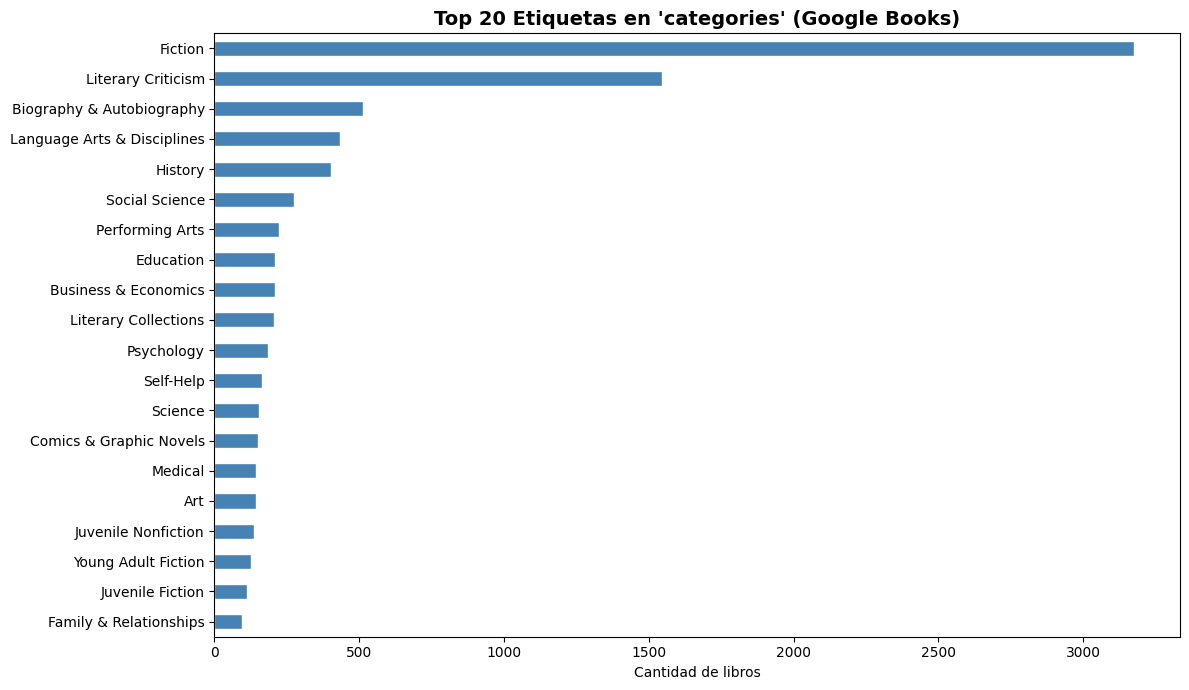

In [ ]:
# ============================================================
# ANÁLISIS DE CATEGORÍAS
# 'assigned_category' es la categoría limpia (una por libro)
# 'categories' es el campo original de Google Books (puede
# contener listas como "['Fiction', 'Drama', 'Literary']")
#
# Estas etiquetas son clave para el Clustering de Fase 4:
# nos ayudan a entender en qué géneros se mueve el lector.
# ============================================================

print("--- ANÁLISIS DE 'assigned_category' ---\n")

cat_counts = df['assigned_category'].value_counts()
print(f"   Categorías únicas : {df['assigned_category'].nunique()}")
print(f"\n   Distribución completa:")
print(cat_counts.to_string())

# Gráfico de assigned_category
fig, ax = plt.subplots(figsize=(12, 7))
cat_counts.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title("Distribución de Categorías Asignadas", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de libros")
# Línea vertical con la media: nos dice cuántos libros tiene
# una categoría "promedio"
ax.axvline(
    x=cat_counts.mean(),
    color='red', linestyle='--', alpha=0.7,
    label=f'Media: {cat_counts.mean():.0f} libros'
)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# ANÁLISIS DE 'categories' (campo original de Google Books)
# Puede tener formato string de lista: "['Fiction', 'Drama']"
# Lo parseamos para ver todas las etiquetas individuales
# ============================================================
print("\n--- ANÁLISIS DE 'categories' (campo original) ---\n")

print("   Muestra de valores crudos:")
print(df['categories'].dropna().head(8).to_list())

def parse_categories(val):
    """
    Convierte "['Fiction', 'Drama']" (string) en ['Fiction', 'Drama'] (lista Python).
    Si ya es un string simple como "Fiction", lo devuelve como lista de un elemento.
    """
    if pd.isna(val):
        return []
    try:
        result = ast.literal_eval(val)   # Intenta convertir string a lista Python
        return result if isinstance(result, list) else [str(result)]
    except:
        return [str(val)]                # Si falla, trata el valor como categoría simple

df['categories_list'] = df['categories'].apply(parse_categories)

# Aplanamos todas las listas en una sola lista de etiquetas
all_cats    = [c for sublist in df['categories_list'] for c in sublist]
cat_counter = Counter(all_cats)

print(f"\n   Total etiquetas únicas en 'categories' : {len(cat_counter)}")
print(f"\n   Top 20 etiquetas:")
for cat, count in cat_counter.most_common(20):
    print(f"     {cat:<40} {count:>5} libros")

# Gráfico top 20 etiquetas de 'categories'
top20_cats = pd.Series(dict(cat_counter.most_common(20)))
fig, ax = plt.subplots(figsize=(12, 7))
top20_cats.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Top 20 Etiquetas en 'categories' (Google Books)", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de libros")
plt.tight_layout()
plt.show()


--- ANÁLISIS DE AUTORES ---

   Autores únicos : 7,036
   Nulos          : 0

   Autores con 1 solo libro  : 5,970
   Autores con 2-5 libros    : 786
   Autores con más de 5      : 280
   Autores con más de 10     : 125

   Top 20 autores con más libros:
authors
Gene Wolfe              24
Conn Iggulden           23
Gardner Dozois          22
Terry Pratchett         20
Patricia A. McKillip    20
David Foster Wallace    20
Sophie Hannah           20
Lindsey Davis           19
Guy Gavriel Kay         19
Ursula K. Le Guin       19
Paul Auster             19
Ann Cleeves             19
Dennis Lehane           19
Michael Connelly        19
Agatha Christie         19
Lord Dunsany            18
Laura Lippman           18
Raymond Chandler        18
Philip K. Dick          18
Ali Smith               18


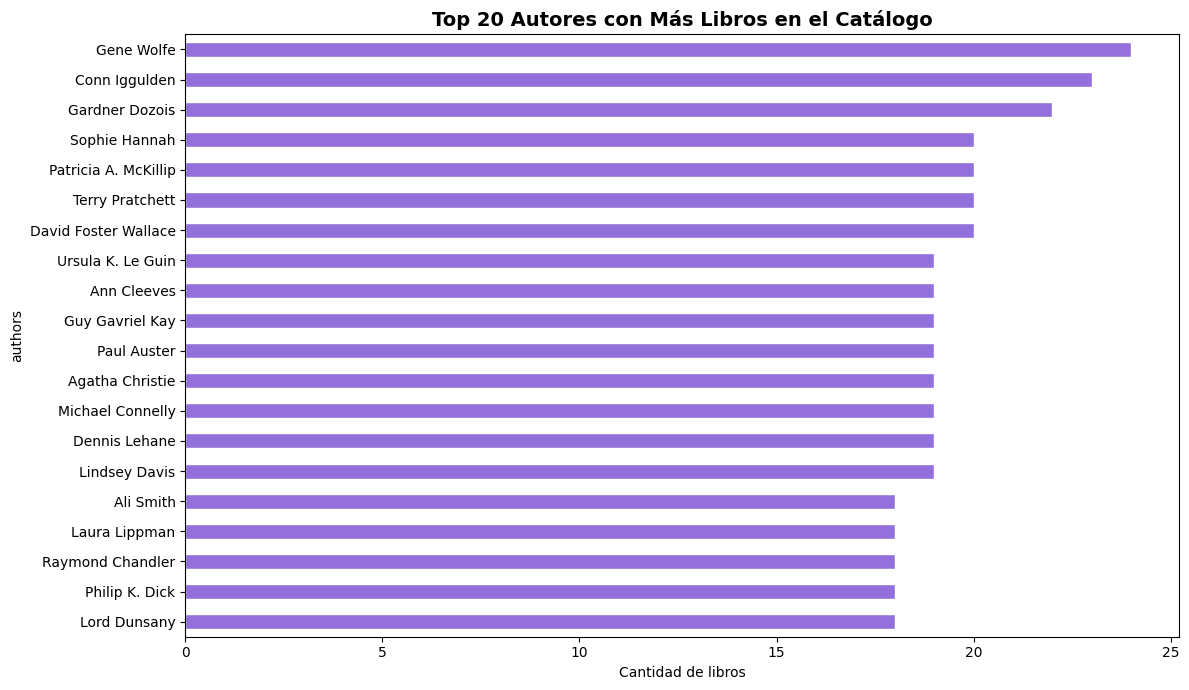

In [ ]:
# ============================================================
# ANÁLISIS DE AUTORES
# Nos interesa saber cuántos autores únicos hay y si hay
# autores muy dominantes que puedan sesgar las recomendaciones
# ============================================================

print("--- ANÁLISIS DE AUTORES ---\n")

print(f"   Autores únicos : {df['authors'].nunique():,}")
print(f"   Nulos          : {df['authors'].isna().sum()}")

# Distribución: cuántos libros tiene cada autor
libros_por_autor = df['authors'].value_counts()

print(f"\n   Autores con 1 solo libro  : {(libros_por_autor == 1).sum():,}")
print(f"   Autores con 2-5 libros    : {((libros_por_autor >= 2) & (libros_por_autor <= 5)).sum():,}")
print(f"   Autores con más de 5      : {(libros_por_autor > 5).sum():,}")
print(f"   Autores con más de 10     : {(libros_por_autor > 10).sum():,}")

print(f"\n   Top 20 autores con más libros:")
print(libros_por_autor.head(20).to_string())

# Gráfico top 20 autores
fig, ax = plt.subplots(figsize=(12, 7))
libros_por_autor.head(20).sort_values().plot(
    kind='barh', ax=ax, color='mediumpurple', edgecolor='white'
)
ax.set_title("Top 20 Autores con Más Libros en el Catálogo", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de libros")
plt.tight_layout()
plt.show()




--- ANÁLISIS DE AÑO DE PUBLICACIÓN ---

   Nulos : 141
   Rango completo : 1820 — 2027
   Años fuera de rango (< 1800 o > 2025) : 125
   Libros con año válido : 10,685


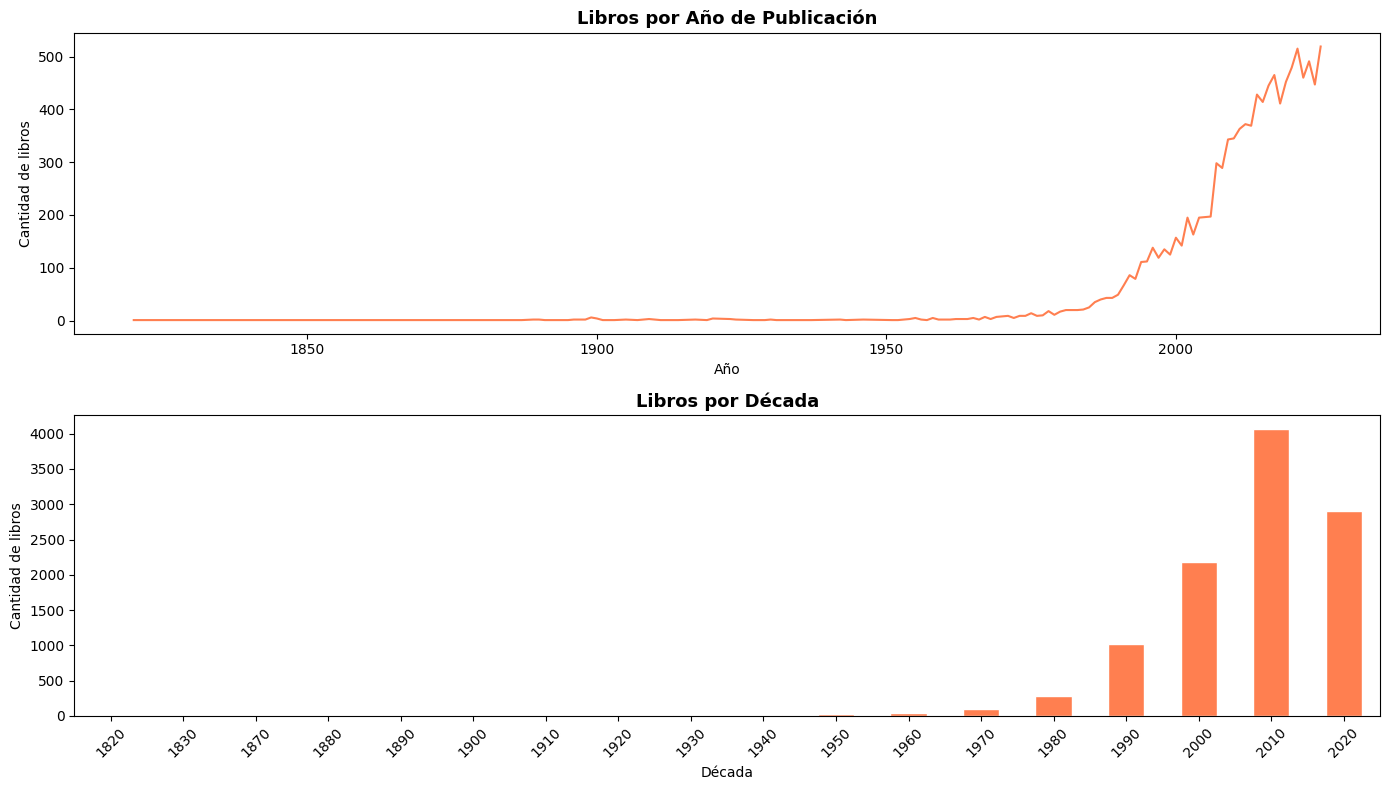

In [ ]:
# ============================================================
# ANÁLISIS DE AÑO DE PUBLICACIÓN
# Nos dice qué tan contemporáneo es el catálogo.
# También detectamos valores raros (años imposibles).
# ============================================================

print("\n--- ANÁLISIS DE AÑO DE PUBLICACIÓN ---\n")

print(f"   Nulos : {df['year'].isna().sum():,}")
print(f"   Rango completo : {df['year'].min():.0f} — {df['year'].max():.0f}")

# Detectar años fuera de rango lógico
fuera_rango = df[(df['year'] < 1800) | (df['year'] > 2025)].shape[0]
print(f"   Años fuera de rango (< 1800 o > 2025) : {fuera_rango}")

# Filtrar rango válido para el análisis
df_year = df[(df['year'] >= 1800) & (df['year'] <= 2025)]
print(f"   Libros con año válido : {len(df_year):,}")

# Décadas: agrupamos por década para ver tendencias más claras
df_year = df_year.copy()
df_year['decada'] = (df_year['year'] // 10 * 10).astype(int)
decadas = df_year['decada'].value_counts().sort_index()

# Gráfico por año
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Arriba: evolución por año
df_year['year'].value_counts().sort_index().plot(
    ax=axes[0], color='coral', linewidth=1.5
)
axes[0].set_title("Libros por Año de Publicación", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Cantidad de libros")

# Abajo: por década (más legible para tendencias largas)
decadas.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Libros por Década", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Década")
axes[1].set_ylabel("Cantidad de libros")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# FILTRO 2 — Año de publicación
# ============================================================
# Eliminamos libros con años fuera de rango plausible:
#
# < 1800: textos pre-modernos raramente aparecen en Google Books
#   con metadatos fiables.
# > 2025: fechas futuras son errores de entrada de datos.
#
# NaN: los conservamos — el año no se usa en ningún paso del
# pipeline (NLP, clustering, RAG). Eliminarlos reduciría el
# catálogo innecesariamente.

YEAR_MIN = 1800
YEAR_MAX = 2025

before = len(df_filtrado)

year_out_of_range = (
    df_filtrado['year'].notna() &
    ((df_filtrado['year'] < YEAR_MIN) | (df_filtrado['year'] > YEAR_MAX))
)

df_filtrado = df_filtrado[~year_out_of_range].copy()

print("--- FILTRO 2: Año de publicación ---\n")
print(f"   Antes del filtro : {before:,} libros")
print(f"   Eliminados       : {year_out_of_range.sum():,} libros (año < {YEAR_MIN} o > {YEAR_MAX})")
print(f"   Años NaN conservados : {df_filtrado['year'].isna().sum():,} libros")
print(f"   Actualizado      : {len(df_filtrado):,} libros")

--- FILTRO 2: Año de publicación ---

   Antes del filtro : 9,963 libros
   Eliminados       : 0 libros (año < 1800 o > 2025)
   Años NaN conservados : 123 libros
   Actualizado      : 9,963 libros


## [Development History] Deduplicación v1

Primera versión del algoritmo de deduplicación fuzzy (umbral de título: 88).  
Generaba demasiados falsos positivos: colecciones de volúmenes como *"Books 7–9"* y *"Books 10–12"*  
se marcaban como duplicados porque la base del título era similar.


## [Development History] Deduplicación v2

Segunda iteración subiendo el umbral de 88 → 92  
y añadiendo detección de números de volumen/serie (`PATRONES_VOLUMEN`).  
Resolvió el problema de falsos positivos con series numeradas.  
Aún tenía casos límite con ediciones anotadas/ilustradas.


In [ ]:
# ============================================================
# DEDUPLICACIÓN FUZZY — VERSIÓN FINAL
# Regla simple: un libro por autor.
# Si dos títulos son del mismo autor y parecen el mismo libro
# (incluyendo ediciones anotadas, ilustradas, resumidas, etc.)
# nos quedamos con el que tiene la descripción más larga.
# ============================================================

from rapidfuzz import fuzz
import re

PATRONES_VOLUMEN = [
    r'\bbooks?\s*\d',
    r'\bvol(ume)?\s*\.?\s*\d',
    r'\bpart\s*\d',
    r'\b(box\s*set)',
    r'#\s*\d',
    r'\bdeluxe\s*\d',
    r'\b(omnibus)',
    r'\d+\s*-\s*\d+',
]

def tiene_numero_volumen(titulo):
    titulo_lower = titulo.lower()
    for patron in PATRONES_VOLUMEN:
        if re.search(patron, titulo_lower):
            return True
    return False

def normalizar(texto):
    if pd.isna(texto) or texto == "":
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def apellido(autor):
    norm = normalizar(autor)
    if not norm:
        return ""
    partes = norm.split()
    return partes[-1] if partes else ""

def mismo_autor(autor1, autor2, umbral=85):
    ap1 = apellido(autor1)
    ap2 = apellido(autor2)
    if not ap1 or not ap2:
        return False
    if fuzz.ratio(ap1, ap2) >= umbral:
        return True
    if fuzz.ratio(normalizar(autor1), normalizar(autor2)) >= umbral:
        return True
    return False

def mismo_titulo(titulo1, titulo2, umbral=92):
    """
    Regla final:
    - Si alguno tiene número de volumen → solo duplicado si son 98% iguales
    - Resto → umbral 92 o subtítulo contenido
    """
    t1 = normalizar(titulo1)
    t2 = normalizar(titulo2)
    if not t1 or not t2:
        return False

    # Volúmenes y series: solo duplicado si son prácticamente idénticos
    if tiene_numero_volumen(titulo1) or tiene_numero_volumen(titulo2):
        return fuzz.ratio(t1, t2) >= 98

    # Similitud directa
    if fuzz.ratio(t1, t2) >= umbral:
        return True

    # Subtítulo contenido en título más largo
    corto = t1 if len(t1) <= len(t2) else t2
    largo = t2 if len(t1) <= len(t2) else t1
    if len(corto) >= 12 and largo.startswith(corto):
        resto = largo[len(corto):].strip()
        if not re.match(r'^\d', resto):
            return True

    return False

# ============================================================
# EJECUTAR
# ============================================================
# Input: df_filtrado — ya limpiado por los Filtros 1 y 2.
# Ordenamos por longitud de descripción de mayor a menor para que,
# cuando dos libros se marquen como duplicados, conservemos el que
# tiene la descripción más completa.

df_sorted = df_filtrado.sort_values('desc_len', ascending=False).reset_index(drop=True)

print(f"Books to process: {len(df_sorted):,}")
print("Starting fuzzy deduplication...")

indices_finales = []
aceptados_final = []

for i, row in df_sorted.iterrows():
    titulo_i   = normalizar(row['title'])
    apellido_i = apellido(row['authors'])
    es_duplicado = False

    for titulo_a, apellido_a in aceptados_final:
        if not mismo_autor(apellido_i, apellido_a):
            continue
        if mismo_titulo(titulo_i, titulo_a):
            es_duplicado = True
            break

    if not es_duplicado:
        indices_finales.append(i)
        aceptados_final.append((titulo_i, apellido_i))

    if (i + 1) % 1000 == 0:
        print(f"  Processed: {i + 1:,} / {len(df_sorted):,}")

print(f"\nDeduplication complete.")

# ============================================================
# DATASET FINAL
# ============================================================
df_clean = df_sorted.loc[indices_finales].reset_index(drop=True)
df_clean = df_clean.drop(columns=['desc_len', 'categories_list'], errors='ignore')

print("\n" + "=" * 55)
print("DATASET FINAL RESUMEN")
print("=" * 55)
print(f"""
  Dataset original                 : {len(df):,}
  Eliminado (desc < 100 chars)     : {(df['desc_len'] < 100).sum():,}
  Eliminado (desc > 2500 chars)    : {(df['desc_len'] > 2500).sum():,}
  Eliminado (año fuera de rango)   : {len(df[df['desc_len'].between(100, 2500)]) - len(df_filtrado):,}
  Eliminado (duplicados fuzzy)     : {len(df_filtrado) - len(df_clean):,}
  ─────────────────────────────────────────
  DATASET FINAL                  : {len(df_clean):,} books
  Categorías únicas              : {df_clean['assigned_category'].nunique()}
  Autores únicos                 : {df_clean['authors'].nunique():,}
""")

# ============================================================
# GUARDAR EN DRIVE
# ============================================================
SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/PF_Ironhack/books_clean.csv"
df_clean.to_csv(SAVE_PATH, index=False)
print(f"Guardado: {SAVE_PATH}")

Books to process: 9,963
Starting fuzzy deduplication...
  Processed: 1,000 / 9,963
  Processed: 2,000 / 9,963
  Processed: 3,000 / 9,963
  Processed: 4,000 / 9,963
  Processed: 5,000 / 9,963
  Processed: 6,000 / 9,963
  Processed: 7,000 / 9,963
  Processed: 8,000 / 9,963
  Processed: 9,000 / 9,963

Deduplication complete.

DATASET FINAL RESUMEN

  Dataset original                 : 10,951
  Eliminado (desc < 100 chars)     : 451
  Eliminado (desc > 2500 chars)    : 422
  Eliminado (año fuera de rango)   : 115
  Eliminado (duplicados fuzzy)     : 903
  ─────────────────────────────────────────
  DATASET FINAL                  : 9,060 books
  Categorías únicas              : 23
  Autores únicos                 : 6,398

Guardado: /content/drive/MyDrive/Colab Notebooks/PF_Ironhack/books_clean.csv
